# Notebook 1 — Exploration, features et clustering
## Partie 1 · Analyse exploratoire des données (EDA)

**Projet BrainScanAI — détection de tumeurs cérébrales par approche semi-supervisée (CurelyticsIA)**

Cette première partie explore le jeu de données d'IRM cérébrales afin de :
1. **contrôler la qualité** des données (intégrité, format, doublons) ;
2. **détecter les biais** susceptibles de fausser la modélisation ;
3. **éclairer les choix de prétraitement** de la partie suivante (extraction de features).

Le jeu de données se compose de trois ensembles :

| Ensemble | Rôle | Effectif |
|---|---|---|
| `avec_labels/cancer` + `avec_labels/normal` | images **labélisées** (annotées par des radiologues) | 100 |
| `sans_label` | images **non labélisées**, exploitées en semi-supervisé | 1 406 |

> **Règle méthodologique :** les ensembles d'images labélisées et non labélisées doivent rester **strictement séparés** tout au long du projet.

In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATA = Path("../data/mri_dataset_brain_cancer_oc")   # ".." = remonter de notebooks/ vers la racine

# à chaque sous-dossier on associe son label
dossiers = {"avec_labels/cancer": "cancer",
            "avec_labels/normal": "normal",
            "sans_label":         "inconnu"}

lignes = []                                   # on va remplir cette liste
for sous_dossier, label in dossiers.items():
    for chemin in (DATA / sous_dossier).glob("*.jpg"):   # parcourt chaque .jpg
        lignes.append({"chemin": chemin, "source": sous_dossier, "label": label})

df = pd.DataFrame(lignes)
df["label"].value_counts()       # compte les images par label


label
inconnu    1406
cancer       50
normal       50
Name: count, dtype: int64

## 1. Structure et intégrité du jeu de données

Le catalogue confirme **1 506 images** — et non 1 500 comme l'indique la documentation — réparties en 1 406 images non labélisées, 50 « cancer » et 50 « normal ».

- L'ensemble d'images labélisées est **parfaitement équilibré** (50/50) : confortable pour l'entraînement, mais ce ratio ne reflète pas nécessairement la prévalence réelle de la maladie.
- La répartition des classes au sein des images **non labélisées est inconnue** : rien ne garantit qu'elle soit équilibrée. À garder en tête lors de l'interprétation du clustering.

Premier contrôle : les fichiers sont-ils **corrompus** ?

In [3]:
corrompus = []
for chemin in df["chemin"]:
    try:
        Image.open(chemin).verify()    # .verify() = "ce fichier est-il une image valide ?"
    except Exception:
        corrompus.append(chemin)
print(len(corrompus), "fichier(s) corrompu(s)")


0 fichier(s) corrompu(s)


**Aucun fichier corrompu** : les 1 506 images s'ouvrent correctement, aucune n'est à écarter pour ce motif.

Deuxième contrôle : l'**homogénéité du format** — dimensions et nature réelle des canaux de couleur.

In [4]:
infos = []
for chemin in df["chemin"]:
    img = Image.open(chemin)
    arr = np.array(img)                                    # image -> tableau de nombres
    gris = np.array_equal(arr[:, :, 0], arr[:, :, 2])      # canal R == canal B ?
    infos.append({"taille": img.size, "mode": img.mode, "gris_duplique": gris})

infos_df = pd.DataFrame(infos)
print(infos_df["taille"].value_counts())
print(infos_df["gris_duplique"].value_counts())


taille
(512, 512)    1506
Name: count, dtype: int64
gris_duplique
True     1496
False      10
Name: count, dtype: int64


**Format homogène, à une nuance près :**

- Toutes les images mesurent **512 × 512** : aucune normalisation de taille n'est nécessaire.
- Pour **1 496 images sur 1 506**, le canal rouge et le canal bleu sont identiques — signature d'une image en **niveaux de gris dupliquée** sur les trois canaux, ce qui est attendu pour des IRM.
- **10 images font exception** (R ≠ B) : 9 dans `sans_label`, 1 dans `normal`. Il s'agit vraisemblablement d'artefacts de compression JPEG plutôt que de vraies couleurs, mais ces cas seront à surveiller.

> **Conséquence pour le prétraitement :** on pourra travailler sur **un seul canal** (niveaux de gris) sans perte d'information pour la quasi-totalité des images.

Troisième contrôle, le plus sensible : la présence de **doublons**.

In [5]:
import hashlib

def empreinte(chemin):
    return hashlib.md5(chemin.read_bytes()).hexdigest()   # lit les octets -> empreinte

df["hash"] = df["chemin"].apply(empreinte)                # .apply = applique la fonction à chaque ligne
doublons = df[df["hash"].duplicated(keep=False)]          # garde les lignes qui partagent un hash
print(len(doublons), "image(s) en doublon")
doublons.sort_values("hash")[["source", "hash"]]          # pour voir d'où viennent les paires


186 image(s) en doublon


,source,hash
1423,sans_label,038bd3a36c6463f3a9f18ac031ea1c4d
833,sans_label,038bd3a36c6463f3a9f18ac031ea1c4d
938,sans_label,0652cb55477c4edeea5c5dfd53944e3b
51,avec_labels/normal,0652cb55477c4edeea5c5dfd53944e3b
87,avec_labels/normal,0816537db58c1d8092808f2c6f75e96c
...,...,...
1357,sans_label,fa2f6066ee4f4e22f35c46c4ddf8584b
168,sans_label,fdc753e2225fcf328308438eb4f37058
363,sans_label,fdc753e2225fcf328308438eb4f37058
476,sans_label,fe822536fc06483aeea76f22e3709f50


### Doublons : un point critique pour la validité du projet

La recherche par empreinte **MD5** (copies octet pour octet) révèle **186 images en doublon**, regroupées en **90 couples disctincts** (84 paires et 6 triplets). Leur nature est déterminante :

| Type de doublon | Nombre de groupes | Enjeu |
|---|---|---|
| Interne à `sans_label` | 59 | Redondance qui gonfle artificiellement les images non labélisées |
| **Fuite images labélisées ↔ `sans_label`** | **31** | **Fuite de données entre les deux ensembles** |

Concrètement, **32 des 100 images labélisées (8 « cancer », 24 « normal ») possèdent une copie exacte dans `sans_label`**. C'est un problème majeur : en prédisant naïvement des pseudo-labels sur les images non labélisées, on « redécouvrirait » des images dont le label est déjà connu, ce qui **fausserait l'évaluation semi-supervisée** (la même image se retrouverait des deux côtés de l'expérience).

> **Décision :** un **dédoublonnage** sera réalisé avant la modélisation — retrait des clones des images labélisées présents dans `sans_label`, et suppression des redondances internes — afin de préserver l'étanchéité des deux ensembles. Point rassurant : **aucune contradiction de label** (même image classée à la fois « cancer » et « normal ») n'a été détectée.

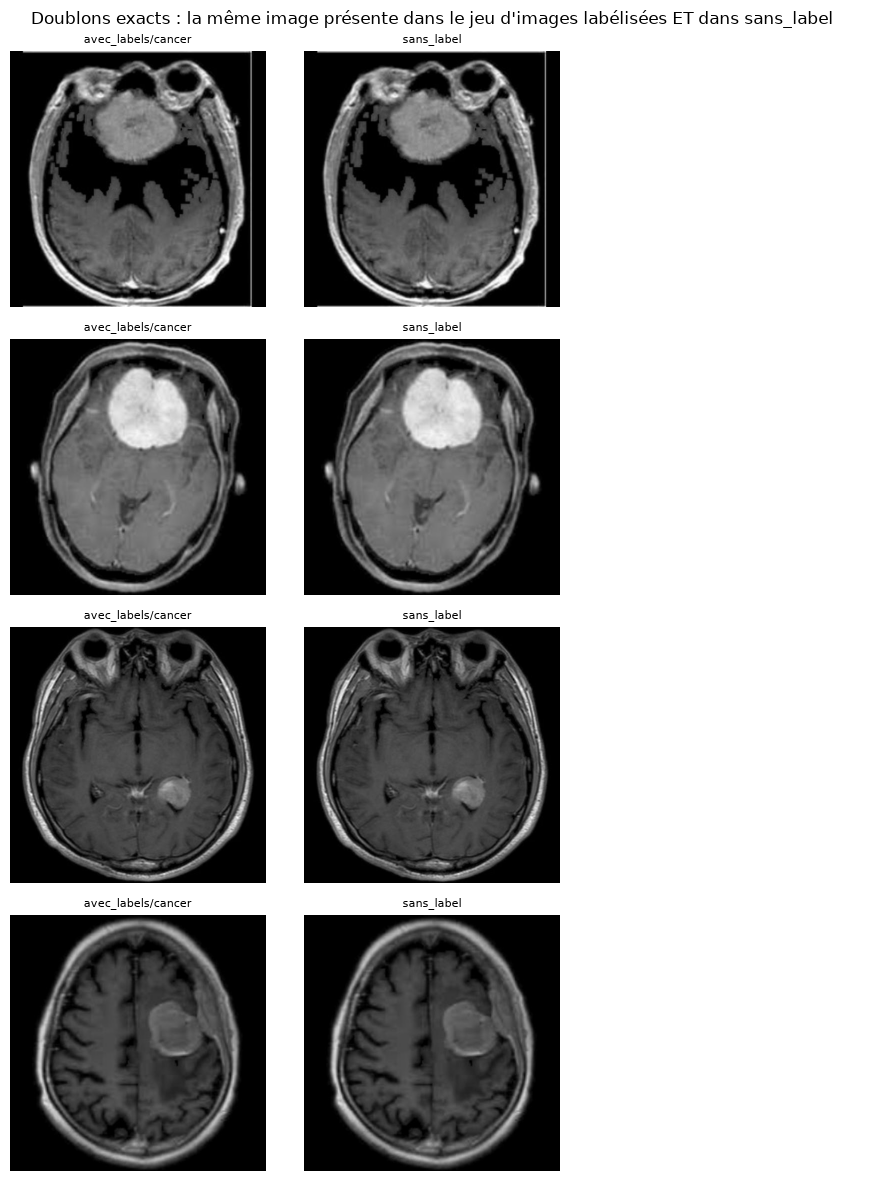

In [6]:
# Visualisation de groupes de doublons EXACTS traversant images labélisées <-> sans_label (la "fuite")
hashes_fuite = doublons[doublons["source"].str.startswith("avec_labels")]["hash"].unique()[:4]

fig, axes = plt.subplots(len(hashes_fuite), 3, figsize=(9, 3 * len(hashes_fuite)), squeeze=False)
for r, h in enumerate(hashes_fuite):
    grp = doublons[doublons["hash"] == h].reset_index(drop=True)   # toutes les images de ce groupe
    for c in range(3):
        ax = axes[r, c]
        if c < len(grp):
            ax.imshow(Image.open(grp.loc[c, "chemin"]), cmap="gray")
            ax.set_title(grp.loc[c, "source"], fontsize=8)
        ax.axis("off")
fig.suptitle("Doublons exacts : la même image présente dans le jeu d'images labélisées ET dans sans_label")
fig.tight_layout()

## 2. Inspection visuelle et caractéristiques d'intensité

Après les contrôles de structure, examinons les images elles-mêmes. Commençons par afficher quelques exemples de chaque classe labélisée.

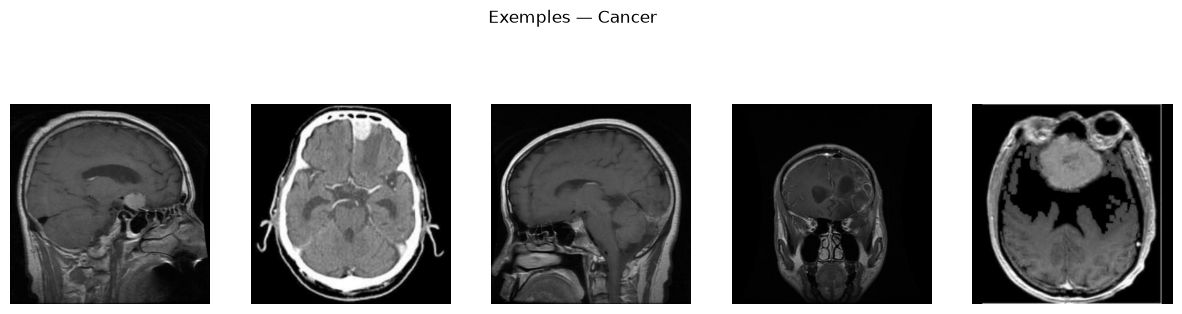

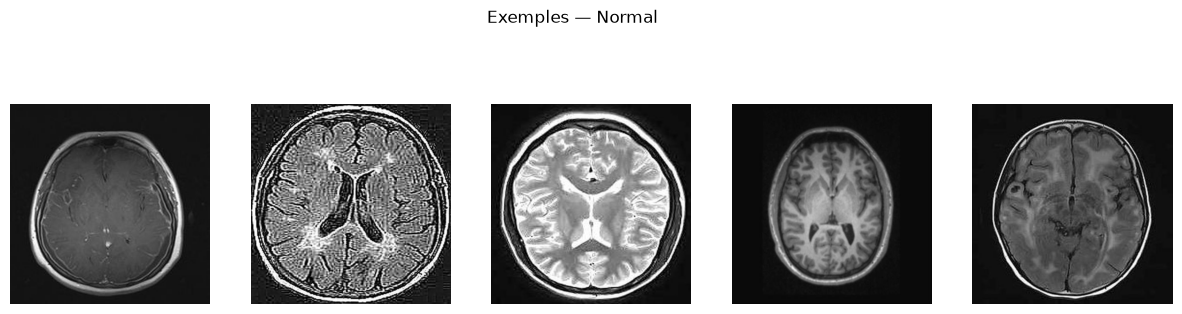

In [7]:
def montrer(chemins, titre):
    fig, axes = plt.subplots(1, len(chemins), figsize=(15, 4))
    for ax, chemin in zip(axes, chemins):      # zip = associe une case à un chemin
        ax.imshow(Image.open(chemin), cmap="gray")
        ax.axis("off")
    fig.suptitle(titre)

montrer(df[df.label == "cancer"]["chemin"].head(5).tolist(), "Exemples — Cancer")
montrer(df[df.label == "normal"]["chemin"].head(5).tolist(), "Exemples — Normal")


À l'œil nu, **aucune différence évidente d'un point de vue caractéristique générale d'image** ne distingue les images « cancer » des « normal » : la signature pathologique n'est pas triviale visuellement. Passons donc à des caractéristiques **quantitatives** — luminosité, contraste, distribution des intensités.

<Axes: xlabel='luminosite', ylabel='Count'>

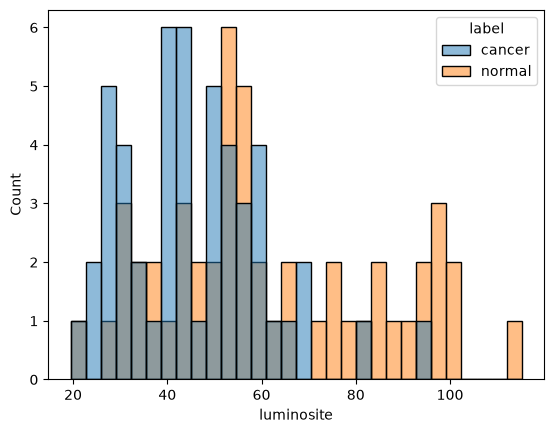

In [8]:
df["luminosite"] = df["chemin"].apply(lambda c: np.array(Image.open(c).convert("L")).mean())

import seaborn as sns
images_labelisees = df[df.label != "inconnu"]                       # on compare cancer vs normal
sns.histplot(data=images_labelisees, x="luminosite", hue="label", bins=30)


La distribution de la luminosité moyenne révèle un **léger décalage** entre les deux classes (les images « normal » tendent à être plus claires). Quantifions cet écart avec des statistiques plus complètes : **contraste** et **proportion de fond noir**.

In [9]:
def stats(chemin):
    arr = np.array(Image.open(chemin).convert("L"), dtype=float)
    return pd.Series({
        "moy":       arr.mean(),          # luminosité
        "contraste": arr.std(),           # dispersion des intensités
        "p_noir":    (arr < 10).mean(),   # part de pixels ~noirs (fond)
    })

df = pd.concat([df, df["chemin"].apply(stats)], axis=1)   # ajoute 3 colonnes
df.groupby("label")[["moy", "contraste", "p_noir"]].describe()


moy                                                         \
          count       mean        std        min        25%        50%   
label                                                                    
cancer     50.0  46.020369  15.504542  19.505821  32.521709  43.576418   
inconnu  1406.0  52.294064  17.063354  14.945938  41.377893  50.226740   
normal     50.0  61.754507  23.577136  21.543587  43.369894  55.338778   

                               contraste             ...             \
               75%         max     count       mean  ...        75%   
label                                                ...              
cancer   56.222936   93.976402      50.0  44.466629  ...  47.093360   
inconnu  59.035653  136.216469    1406.0  48.672533  ...  53.771674   
normal   81.126461  115.188698      50.0  61.072571  ...  73.928577   

                     p_noir                                                    \
                max   count      mean       std       min       25%       50%   
label                                                                           
cancer    79.056616    50.0  0.406074  0.135164  0.142021  0.289446  0.386328   
inconnu  119.179042  1406.0  0.361620  0.137161  0.000000  0.280648  0.363338   
normal    90.388202    50.0  0.306850  0.217583  0.000080  0.088313  0.355343   

                             
              75%       max  
label                        
cancer   0.513166  0.681229  
inconnu  0.438424  0.755577  
normal   0.485774  0.737499  

[3 rows x 24 columns]

Les statistiques révèlent des **différences systématiques** entre classes :

| Classe | Luminosité moyenne | Contraste moyen | Part de fond noir |
|---|---|---|---|
| cancer | 46,0 | 44,5 | **40,6 %** |
| normal | 61,8 | 61,1 | **30,7 %** |

Les images « cancer » sont en moyenne **plus sombres, moins contrastées et comportent davantage de fond noir** que les « normal ».

> **Signal de biais potentiel :** si ces différences *globales* (et non la tumeur elle-même) suffisent à séparer les classes, un modèle pourrait apprendre un **raccourci** plutôt que la pathologie. Nous le confronterons à l'analyse spatiale ci-dessous.

Regardons à présent l'**histogramme moyen des intensités** par classe (niveaux de gris de 0 à 255).

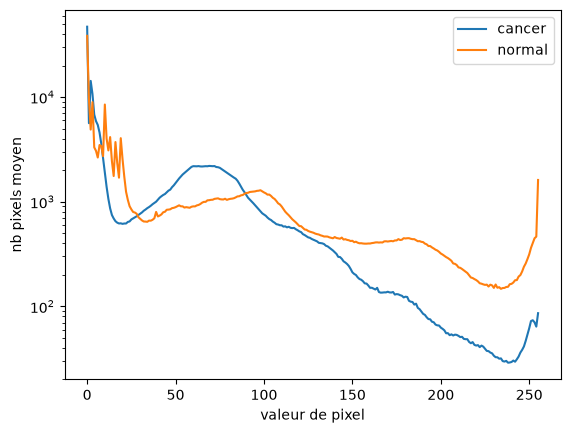

In [10]:
def histo_moyen(chemins):
    cumul = np.zeros(256)
    for c in chemins:
        arr = np.array(Image.open(c).convert("L"))
        cumul += np.bincount(arr.ravel(), minlength=256)   # .ravel() aplatit l'image en 1 ligne
    return cumul / len(chemins)

for label in ["cancer", "normal"]:
    plt.plot(histo_moyen(df[df.label == label]["chemin"]), label=label)
plt.legend(); plt.xlabel("valeur de pixel"); plt.ylabel("nb pixels moyen"); plt.yscale("log")


L'histogramme moyen (échelle logarithmique) montre des **formes globalement similaires** entre les deux classes : un pic marqué à gauche correspondant au **fond noir**, puis la distribution des **tissus** vers la droite. Les niveaux diffèrent toutefois — les « normal » comptent davantage de pixels clairs — ce qui est cohérent avec les statistiques précédentes.

Pour localiser **où** les classes diffèrent spatialement, calculons l'**image moyenne** de chaque classe (moyenne pixel à pixel), puis leur **carte de différence** (`moyenne cancer − moyenne normal`).

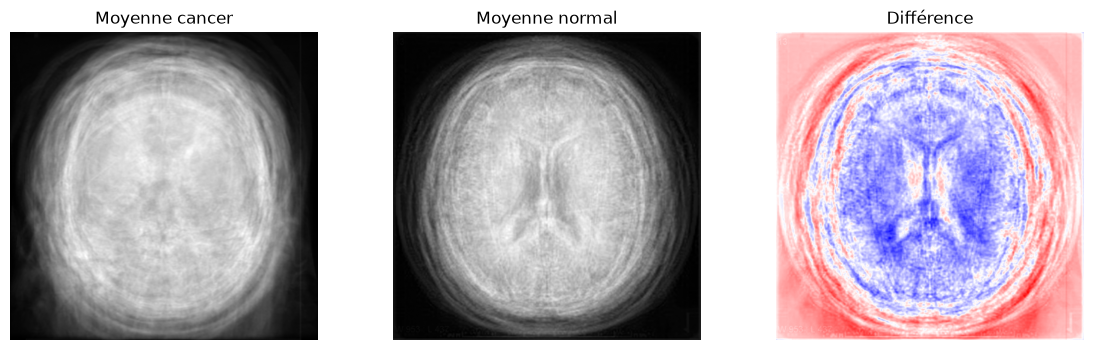

In [11]:
def image_moyenne(chemins):
    somme = np.zeros((512, 512))
    for c in chemins:
        somme += np.array(Image.open(c).convert("L"), dtype=float)
    return somme / len(chemins)

moy_c = image_moyenne(df[df.label == "cancer"]["chemin"])
moy_n = image_moyenne(df[df.label == "normal"]["chemin"])

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(moy_c, cmap="gray");          ax[0].set_title("Moyenne cancer")
ax[1].imshow(moy_n, cmap="gray");          ax[1].set_title("Moyenne normal")
ax[2].imshow(moy_c - moy_n, cmap="bwr");   ax[2].set_title("Différence")   # rouge/bleu = écarts
for a in ax: a.axis("off")


La carte de différence est **éclairante — et préoccupante** : les écarts se concentrent **sur les bords du champ de vue**, et non dans la région cérébrale. Ce qui distingue le plus « cancer » de « normal » relève donc du **cadrage / positionnement** (probablement lié au protocole d'acquisition), pas de la tumeur. Le **risque de raccourci** est ainsi confirmé spatialement : sans précaution, un modèle apprendrait la position plutôt que la pathologie.

> **Piste de prétraitement (Partie 2) :** recadrer / normaliser les images pour atténuer ce biais de bordure.

Dernier volet qualité : certaines images sont-elles **trop floues** pour être exploitables ? La **variance du Laplacien** mesure la netteté (le Laplacien détecte les contours ; sa variance s'effondre sur une image floue).

In [12]:
import cv2
def nettete(chemin):
    arr = np.array(Image.open(chemin).convert("L"))
    return cv2.Laplacian(arr, cv2.CV_64F).var()   # bas = flou

df["nettete"] = df["chemin"].apply(nettete)
df["nettete"].describe()


count    1506.000000
mean      120.133386
std       357.253956
min         8.265243
25%        38.195068
50%        54.756620
75%        79.776623
max      5745.799517
Name: nettete, dtype: float64

La netteté **varie fortement** : médiane ≈ 55, mais étendue de 8 à 5 746. La moyenne (120), très supérieure à la médiane, traduit la présence de quelques images **exceptionnellement nettes** qui tirent la distribution vers le haut — et non une masse d'images floues. Le bas de la distribution (≈ 8 à 38) mériterait une **vérification visuelle** avant toute décision.

> À ce stade, **aucune exclusion automatique** n'est prononcée pour cause de flou : on n'écarte pas une image sur un seuil arbitraire sans l'avoir inspectée. Un tri ciblé pourra être fait après examen des cas extrêmes.

Enfin, au-delà des doublons **exacts** (MD5), recherchons les **quasi-doublons** : des images visuellement très proches (recompressées, légèrement modifiées) que le hash exact ne détecte pas. Le *perceptual hash* (`phash`) attribue un code voisin à des images similaires ; une faible **distance de Hamming** entre deux `phash` signale un quasi-doublon. La cellule suivante compare, à titre d'illustration, une image de référence à toutes les autres ; nous procédons **ensuite** à une recherche systématique des paires proches sur l'ensemble du jeu.

In [13]:
import imagehash
df["phash"] = df["chemin"].apply(lambda c: imagehash.phash(Image.open(c)))
# exemple : comparer une image à toutes les autres -> distance de Hamming
ref = df["phash"].iloc[0]
(df["phash"].apply(lambda h: ref - h)).sort_values().head()   # les plus proches


0        0
931     10
981     12
1206    14
241     16
Name: phash, dtype: int64

In [14]:
# Recherche systématique de quasi-doublons sur les 1506 images (distance de Hamming entre phash)
# 1) chaque phash -> un vecteur de 64 bits (0/1)
bits = np.array([h.hash.flatten() for h in df["phash"]]).astype(np.int16)
# 2) matrice des distances deux a deux : D[i, j] = nombre de bits differents
D = bits @ (1 - bits).T + (1 - bits) @ bits.T
# 3) on ne garde que les paires (i < j) sous un seuil (5 = tres ressemblantes ; au-dela, trop de faux positifs)
SEUIL = 5
i, j = np.triu_indices(len(df), k=1)
proches = D[i, j] <= SEUIL
paires = pd.DataFrame({
    "a": i[proches], "b": j[proches], "distance": D[i, j][proches],
    "source_a": df["source"].values[i[proches]],
    "source_b": df["source"].values[j[proches]],
    "meme_octet": df["hash"].values[i[proches]] == df["hash"].values[j[proches]],   # deja vu par MD5 ?
})
# fuite = une image labélisée ressemble a une image sans_label
paires["fuite"] = (paires["source_a"].str.startswith("avec_labels") | paires["source_b"].str.startswith("avec_labels")) \
                  & ((paires["source_a"] == "sans_label") | (paires["source_b"] == "sans_label"))

print(f"Seuil phash <= {SEUIL} : {len(paires)} paires proches")
print(f"  - {(~paires['meme_octet']).sum()} NOUVELLES (quasi-doublons non detectes par MD5)")
print(f"  - {paires['fuite'].sum()} traversent images labélisées <-> sans_label (fuite)")
paires.sort_values("distance").head(10)

Seuil phash <= 5 : 281 paires proches
  - 179 NOUVELLES (quasi-doublons non detectes par MD5)
  - 56 traversent images labélisées <-> sans_label (fuite)


,a,b,distance,source_a,source_b,meme_octet,fuite
0,4,999,0,avec_labels/cancer,sans_label,True,True
147,354,1446,0,sans_label,sans_label,True,False
151,364,479,0,sans_label,sans_label,False,False
152,389,1227,0,sans_label,sans_label,True,False
153,400,680,0,sans_label,sans_label,False,False
155,403,1025,0,sans_label,sans_label,True,False
157,410,906,0,sans_label,sans_label,True,False
161,421,847,0,sans_label,sans_label,False,False
162,426,611,0,sans_label,sans_label,True,False
146,354,450,0,sans_label,sans_label,True,False


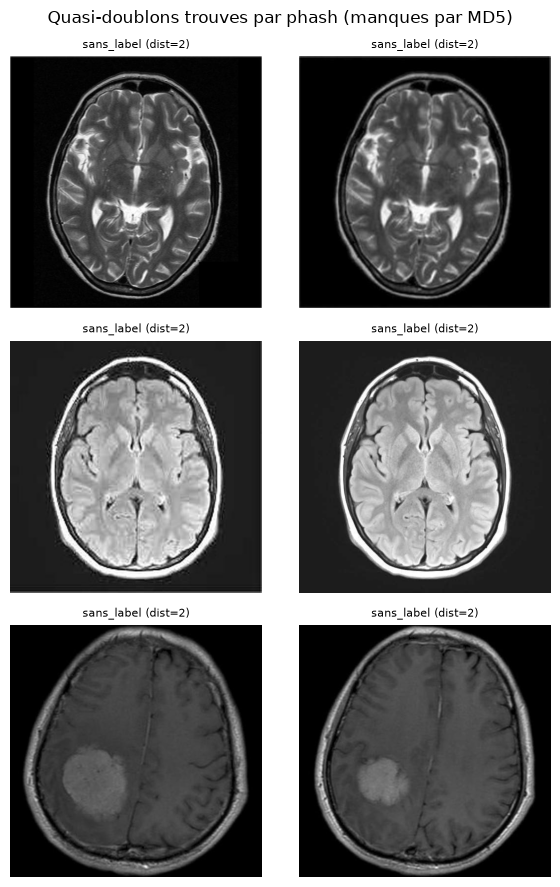

In [15]:
# Quelques quasi-doublons detectes par phash mais PAS par MD5 (octets differents, image quasi identique)
nouveaux = paires[(~paires["meme_octet"]) & (paires["distance"] > 0)].sort_values("distance").head(3)

fig, axes = plt.subplots(len(nouveaux), 2, figsize=(6, 3 * len(nouveaux)), squeeze=False)
for r, (_, p) in enumerate(nouveaux.iterrows()):
    for c, idx in enumerate([p["a"], p["b"]]):
        ax = axes[r, c]
        ax.imshow(Image.open(df.iloc[idx]["chemin"]), cmap="gray")
        ax.set_title(f'{df.iloc[idx]["source"]} (dist={p["distance"]})', fontsize=8)
        ax.axis("off")
fig.suptitle("Quasi-doublons trouves par phash (manques par MD5)")
fig.tight_layout()

La recherche systématique (distance de Hamming entre `phash`, **seuil ≤ 5**) confirme et **étend** le constat des doublons exacts :

- **281 paires** d'images très ressemblantes, dont **179 que le hash MD5 n'avait pas détectées** (copies recompressées : mêmes pixels ou presque, mais octets différents).
- **56 de ces paires traversent la frontière entre les images labélisées et `sans_label`** : la fuite est donc plus large que les seuls doublons exacts.

> Au-delà de ce seuil, le nombre de paires « proches » explose (plus de 1 000 à une distance de 10) : comme toutes les IRM se ressemblent (même organe, même cadrage), un seuil lâche capture de **fausses** ressemblances. On reste donc volontairement **conservateur (≤ 5)**.
>
> **Conséquence :** le dédoublonnage de la Partie 2 s'appuiera sur les doublons exacts **et** sur ces quasi-doublons pour fiabiliser la séparation des ensembles.

Dernier contrôle de cette exploration : un **nuage de points contraste × luminosité**, coloré par label. Si les deux classes se séparaient déjà nettement sur ces deux caractéristiques triviales, ce serait le signe d'un **biais fort** (des données « trop faciles », potentiellement trompeuses). Si elles se chevauchent, le signal utile est **subtil** : plus honnête, mais plus exigeant pour la modélisation.

<Axes: xlabel='moy', ylabel='contraste'>

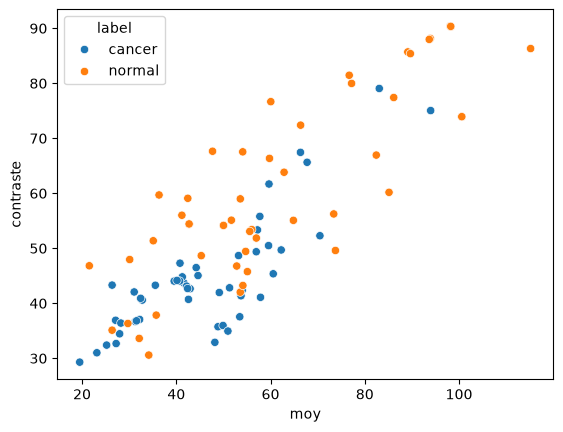

In [16]:
sns.scatterplot(data=df[df.label != "inconnu"], x="moy", y="contraste", hue="label")


Le nuage de points est **plutôt rassurant** : sur ces deux caractéristiques simples, les classes se **chevauchent largement** et ne sont pas séparables par une frontière triviale. Le signal discriminant est donc subtil — ce qui **justifie** le recours à des représentations riches (features issues d'un réseau pré-entraîné) et à des modèles plus complexes dans la suite du projet.

## Synthèse de l'EDA et décisions pour la suite

**Qualité & structure**
- 1 506 images (vs 1 500 annoncées), toutes en 512 × 512, **aucune corrompue**.
- Format quasi homogène : 1 496 images en niveaux de gris dupliqués, **10 exceptions** (R ≠ B) à surveiller.

**Point critique — doublons & fuite de données**
- **186 images en doublon exact** (90 groupes). **32 images labélisées ont un clone dans `sans_label`** (24 « normal », 8 « cancer ») et 59 groupes de redondances internes à `sans_label`.
- **Dédoublonnage obligatoire** avant la modélisation pour garantir l'étanchéité entre images labélisées et non labélisées.

**Biais identifié — risque de raccourci**
- Différences d'intensité systématiques entre classes (cancer plus sombre, plus de fond noir) **et** carte de différence qui s'allume **sur les bords** → un modèle pourrait apprendre le cadrage, pas la tumeur.
- Prétraitement à concevoir pour **atténuer le biais de bordure et normaliser l'intensité**.

**Difficulté de la tâche**
- Classes **non séparables** sur des caractéristiques simples → signal subtil, justifiant l'extraction de features profondes (réseau pré-entraîné) et des modèles complexes.

**Definition of done — EDA :** comptages vérifiés · intégrité contrôlée · doublons quantifiés et caractérisés · biais documentés · implications pour le prétraitement formulées.

*Prochaine étape (Partie 2) : dédoublonnage, prétraitement adapté, puis extraction de features via un réseau pré-entraîné (ResNet).*

## Partie 2 · Prétraitement et extraction des features

Cette partie transforme chaque image en un **vecteur de caractéristiques (features)** exploitable pour le clustering. Elle se déroule en quatre temps :

1. **dédoublonnage** — appliquer la décision de l'EDA pour garantir l'étanchéité des ensembles ;
2. **prétraitement** adapté au modèle pré-entraîné (format + normalisation ImageNet) ;
3. **extraction des features** via un ResNet50 ;
4. **sauvegarde** des features et du catalogue aligné.

*Note : les biais identifiés en EDA (bordures, intensité) sont documentés mais non corrigés à ce stade ; on conserve le prétraitement standard et on réévaluera si le clustering révèle une structure liée à ces biais.*

In [17]:
# Dédoublonnage exact + quasi-doublons (phash)
# Objectif : conserver les images labélisées en priorité, supprimer les clones de sans_label,
# et retirer les redondances internes qui pourraient biaiser le clustering ou les splits.
SEUIL_PHASH = 5
n = len(df)
parent = list(range(n))

def racine(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i

def unir(a, b):
    ra, rb = racine(a), racine(b)
    if ra != rb:
        parent[rb] = ra

# 1) Doublons exacts MD5
for _, indices in df.groupby("hash").groups.items():
    indices = list(indices)
    for j in indices[1:]:
        unir(indices[0], j)

# 2) Quasi-doublons phash conservateurs (distance de Hamming <= 5)
bits = np.array([h.hash.flatten() for h in df["phash"]]).astype(np.int16)
D = bits @ (1 - bits).T + (1 - bits) @ bits.T
i, j = np.triu_indices(n, k=1)
for a, b in zip(i[D[i, j] <= SEUIL_PHASH], j[D[i, j] <= SEUIL_PHASH]):
    unir(a, b)

# 3) Un représentant par composant : image labélisée prioritaire, sinon première image sans_label
composants = {}
for idx in range(n):
    composants.setdefault(racine(idx), []).append(idx)

indices_gardes, conflits = [], []
for indices in composants.values():
    groupe = df.iloc[indices]
    images_labelisees = groupe[groupe["label"] != "inconnu"]
    if len(images_labelisees) > 0:
        if images_labelisees["label"].nunique() > 1:
            conflits.append(groupe[["chemin", "source", "label", "hash"]])
        indices_gardes.append(images_labelisees.index[0])
    else:
        indices_gardes.append(indices[0])

df_clean = df.loc[sorted(indices_gardes)].reset_index(drop=True)

print("Avant:", len(df), "→ après:", len(df_clean))
print(df_clean["label"].value_counts())
print("Composants de doublons/quasi-doublons :", sum(len(v) > 1 for v in composants.values()))
print("Conflits de labels dans les composants :", len(conflits))

# Vérification d'étanchéité exacte ET perceptuelle entre labélisé et sans_label
h_lab = set(df_clean[df_clean.label != "inconnu"]["hash"])
h_sans = set(df_clean[df_clean.label == "inconnu"]["hash"])
print("Hash communs labélisé/sans_label (doit être 0) :", len(h_lab & h_sans))

bits_clean = np.array([h.hash.flatten() for h in df_clean["phash"]]).astype(np.int16)
D_clean = bits_clean @ (1 - bits_clean).T + (1 - bits_clean) @ bits_clean.T
i_clean, j_clean = np.triu_indices(len(df_clean), k=1)
proches_clean = D_clean[i_clean, j_clean] <= SEUIL_PHASH
paires_clean = pd.DataFrame({
    "a": i_clean[proches_clean],
    "b": j_clean[proches_clean],
    "distance": D_clean[i_clean, j_clean][proches_clean],
})
if len(paires_clean):
    paires_clean["source_a"] = df_clean["source"].values[paires_clean["a"]]
    paires_clean["source_b"] = df_clean["source"].values[paires_clean["b"]]
    paires_clean["fuite"] = (paires_clean["source_a"].str.startswith("avec_labels") | paires_clean["source_b"].str.startswith("avec_labels")) \
        & ((paires_clean["source_a"] == "sans_label") | (paires_clean["source_b"] == "sans_label"))
    nb_fuites_phash = int(paires_clean["fuite"].sum())
else:
    nb_fuites_phash = 0
print(f"Paires phash <= {SEUIL_PHASH} restantes : {len(paires_clean)} | fuites labélisé/sans_label : {nb_fuites_phash}")

Avant: 1506 → après: 1281
label
inconnu    1183
cancer       50
normal       48
Name: count, dtype: int64
Composants de doublons/quasi-doublons : 167
Conflits de labels dans les composants : 0
Hash communs labélisé/sans_label (doit être 0) : 0
Paires phash <= 5 restantes : 0 | fuites labélisé/sans_label : 0


**Résultat du dédoublonnage exact + perceptuel : 1 506 → 1 281 images** (225 doublons ou quasi-doublons retirés). Le jeu propre se compose de **50 « cancer », 48 « normal » et 1 183 non labélisées**.

Le contrôle d'étanchéité est maintenant double :
- **0 hash MD5 commun** entre le jeu d'images labélisées et `sans_label` ;
- **0 paire `phash <= 5` restante** entre le jeu d'images labélisées et `sans_label`.

> **Pourquoi 48 « normal » et non 50 ?** Deux redondances côté « normal » ont été détectées dans les composants de doublons/quasi-doublons. En retirer les copies évite qu'une même image ou une image quasi identique se retrouve dans deux partitions ou influence artificiellement les résultats.
>
> **Pourquoi un seuil `phash <= 5` ?** C'est le seuil conservateur documenté en EDA : il capture les copies exactes ou recompressées sans élargir excessivement aux IRM simplement similaires.

In [18]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.IMAGENET1K_V2   # poids pré-entraînés
preprocess = weights.transforms()          # resize 224 + normalisation ImageNet, clé en main


Passons à l'**extraction des features**. Quelques notions PyTorch mobilisées ici :

- **`.eval()` / geler** : on n'entraîne pas le réseau, on effectue seulement des passages avant (*forward*).
- **Retirer la tête** : la couche de classification finale est remplacée par `Identity()` → la sortie devient le **vecteur de features** (2048 dimensions) au lieu d'une probabilité de classe.
- **`DataLoader`** : charge les images par **paquets (*batches*)** pour exploiter le GPU efficacement.
- **`torch.no_grad()`** : désactive le calcul des gradients (inutile sans entraînement) → plus rapide et moins gourmand en mémoire.

In [19]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
model = resnet50(weights=weights)
model.fc = torch.nn.Identity()      # on coupe la tête → sortie = features
model.eval().to(device)

class ImagesIRM(Dataset):
    def __init__(self, df, transform): self.chemins=df["chemin"].tolist(); self.tf=transform
    def __len__(self): return len(self.chemins)
    def __getitem__(self, i): return self.tf(Image.open(self.chemins[i]).convert("RGB"))

loader = DataLoader(ImagesIRM(df_clean, preprocess), batch_size=64, num_workers=4)

features = []
with torch.no_grad():
    for batch in loader:
        features.append(model(batch.to(device)).cpu().numpy())
features = np.concatenate(features)   # (N, 2048)
print(features.shape)


(1281, 2048)


Les **1 281 vecteurs de features (2 048 dimensions)** sont prêts. Sauvegardons-les, avec le catalogue aligné, afin de les réutiliser dans la partie clustering sans tout recalculer.

In [20]:
np.save("../outputs/features_resnet50.npy", features)
df_clean.assign(chemin=df_clean["chemin"].astype(str))[["chemin","source","label"]] \
        .to_csv("../outputs/catalogue_clean.csv", index=False)

print("NaN ?", np.isnan(features).any(), "| variance moyenne:", features.var(axis=0).mean())

NaN ? False | variance moyenne: 0.038587067


## Synthèse de la Partie 2

- **Dédoublonnage :** 1 506 → **1 281 images**, étanchéité garantie en MD5 **et** en `phash <= 5`. Images labélisées : 50 cancer / 48 normal.
- **Prétraitement :** redimensionnement 224×224, conversion en 3 canaux, **normalisation ImageNet** (convention du transfer learning), via les `transforms` fournis avec les poids ResNet50.
- **Features :** matrice **(1 281, 2 048)** extraite sur GPU avec un ResNet50 gelé, **sans NaN**.
- **Sauvegarde :** `outputs/features_resnet50.npy` + `outputs/catalogue_clean.csv` (même ordre → alignement garanti).

> **À garder pour la Partie 3 :** ces features sortent d'une couche **ReLU** → elles sont **positives et creuses** (beaucoup de zéros). Une **standardisation** (centrage / réduction) est donc pertinente avant la réduction de dimension (PCA / t-SNE) et le clustering.

**Definition of done — Partie 2 :** dédoublonnage validé (étanchéité exacte + perceptuelle = 0) · prétraitement justifié · features exploitables sans NaN · features + catalogue sauvegardés et alignés.

## Partie 3 — Clustering, séparation train/test et pseudo-labélisation (sans fuite)

Cette partie produit, à partir des features, deux livrables pour le Notebook 2 :
le **split train/test** des images labélisées et un lot de **pseudo-labels** fiables.

> **Trois règles anti-fuite** structurent toute la partie :
> 1. on **isole le test dès le départ**, *avant* toute étape supervisée (clustering évalué, pseudo-labels, choix de seuils) ;
> 2. la **standardisation et la PCA sont ajustées sans le test** ;
> 3. les **pseudo-labels sont produits à partir des seules images d'entraînement** (les ancres).

### 3.1 — Recharger les features et sanctuariser le test

On recharge les features ResNet et le catalogue (même ordre → alignement garanti), puis on
sépare **immédiatement** les images labélisées en `train` / `test`. Ce test ne servira qu'au
Notebook 2, pour comparer les modèles ; il n'intervient nulle part dans la fabrication des
pseudo-labels. C'est la correction de la fuite « inter-notebooks » identifiée à la relecture.

In [21]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

features = np.load("../outputs/features_resnet50.npy")
cat = pd.read_csv("../outputs/catalogue_clean.csv")          # MÊME ordre que features

# Masques : images labélisées par l'expert vs pool non labélisé (semi-supervisé).
mask_lab  = (cat["label"] != "inconnu").values
idx_lab   = np.where(mask_lab)[0]
idx_unlab = np.where(~mask_lab)[0]
y_lab     = (cat.loc[mask_lab, "label"].values == "cancer").astype(int)   # cancer = 1

# Règle anti-fuite n°1 : on met le test de côté AVANT tout traitement supervisé.
pos_train, pos_test = train_test_split(
    np.arange(len(idx_lab)), test_size=0.3, stratify=y_lab, random_state=0)
idx_train, idx_test = idx_lab[pos_train], idx_lab[pos_test]
y_train,   y_test   = y_lab[pos_train],   y_lab[pos_test]

print(f"labélisées : {len(idx_lab)} | train : {len(idx_train)} | test sanctuarisé : {len(idx_test)}")
print(f"pool non labélisé : {len(idx_unlab)}")

labélisées : 98 | train : 68 | test sanctuarisé : 30
pool non labélisé : 1183


Le test (30 images) est désormais hors de portée : aucune des étapes suivantes ne le regarde.

### 3.2 — Standardisation et PCA ajustées *sans* le test

K-Means raisonne en distances : on **standardise** (centrage-réduction) pour qu'aucune dimension
ne domine, puis on réduit à 50 composantes par **PCA** (débruitage + accélération).
Règle anti-fuite n°2 : scaler et PCA sont **ajustés sur train + pool uniquement**, jamais sur le test.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fit_idx = np.r_[idx_train, idx_unlab]                 # tout SAUF le test
scaler  = StandardScaler().fit(features[fit_idx])
X       = scaler.transform(features)                  # appliqué à tout, ajusté sans le test

pca   = PCA(n_components=50, random_state=0).fit(X[fit_idx])
X_pca = pca.transform(X)
X_2d  = TSNE(n_components=2, random_state=0, init="pca").fit_transform(X_pca)   # viz uniquement

print(f"X : {X.shape} | PCA : {X_pca.shape} | variance retenue : {pca.explained_variance_ratio_.sum():.0%}")

X : (1281, 2048) | PCA : (1281, 50) | variance retenue : 46%


Les features sont prêtes : 50 composantes retenant ~46 % de la variance, suffisant pour regrouper.

### 3.3 — Benchmark de clustering (évalué sur le train)

L'énoncé demande K-Means et DBSCAN ; on élargit le benchmark (agglomératif, mélange gaussien,
spectral) et on ajoute une baseline **sans PCA** (RAW2048) pour vérifier que la réduction ne dégrade
pas l'accord avec les labels. L'accord se mesure par l'**ARI**, calculé **uniquement sur le train**
(le test reste sanctuarisé).

In [23]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

def ari_train(labels):
    # ARI mesuré sur les seules images du train
    return adjusted_rand_score(y_train, np.asarray(labels)[idx_train])

lignes, etiquettes = [], {}
def evaluer(nom, labels):
    labels = np.asarray(labels); etiquettes[nom] = labels
    lignes.append({"méthode": nom,
                   "clusters": len(set(labels) - {-1}),
                   "bruit": int((labels == -1).sum()),
                   "ARI_train": ari_train(labels)})

for nom, Xr in {"RAW2048": X, "PCA50": X_pca}.items():
    evaluer(f"{nom} KMeans k=2",  KMeans(2, n_init=30, random_state=0).fit_predict(Xr))
    evaluer(f"{nom} Agglo k=2",   AgglomerativeClustering(2, linkage="ward").fit_predict(Xr))
    evaluer(f"{nom} GMM k=2",     GaussianMixture(2, covariance_type="diag", random_state=0).fit_predict(Xr))
for eps in [15, 20, 25]:                                    # DBSCAN ne force pas 2 groupes
    evaluer(f"PCA50 DBSCAN eps={eps}", DBSCAN(eps=eps, min_samples=10).fit_predict(X_pca))
evaluer("PCA50 Spectral", SpectralClustering(2, affinity="nearest_neighbors", n_neighbors=20,
                                             assign_labels="kmeans", random_state=0).fit_predict(X_pca))

benchmark_clustering = pd.DataFrame(lignes).sort_values("ARI_train", ascending=False).reset_index(drop=True)
benchmark_clustering.round(3)

,méthode,clusters,bruit,ARI_train
0,RAW2048 Agglo k=2,2,0,0.450
1,PCA50 Agglo k=2,2,0,0.337
2,PCA50 DBSCAN eps=15,4,834,0.273
3,PCA50 Spectral,2,0,0.240
4,RAW2048 KMeans k=2,2,0,0.096
5,PCA50 KMeans k=2,2,0,0.096
6,RAW2048 GMM k=2,2,0,0.094
7,PCA50 DBSCAN eps=20,1,447,0.022
8,PCA50 DBSCAN eps=25,1,219,-0.003
9,PCA50 GMM k=2,2,0,-0.004


Le meilleur ARI plafonne autour de **0,45** : le clustering capte une structure, mais trop bruitée
pour pseudo-labéliser aveuglément les 1 183 images du pool. On passe donc à une approche **supervisée
ancrée** sur les quelques labels experts.

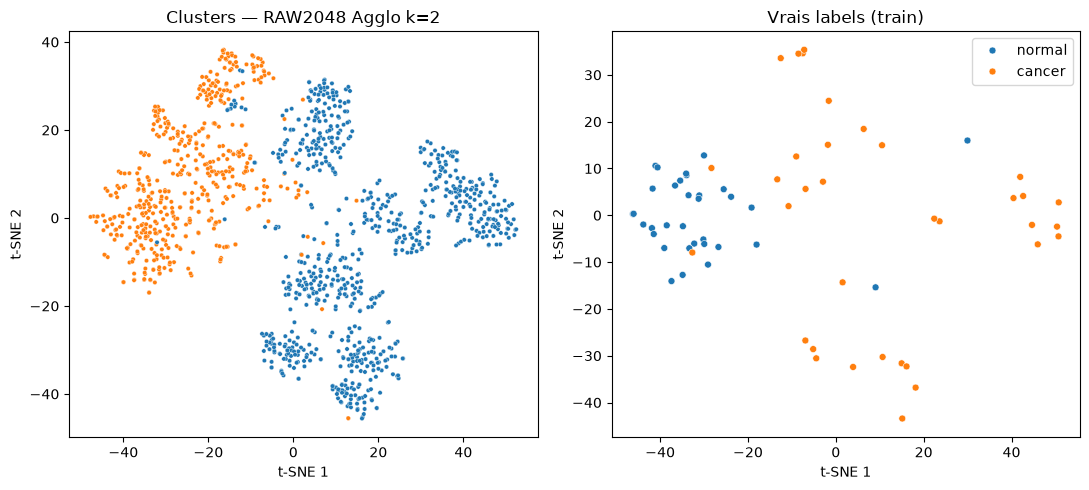

In [24]:
import matplotlib.pyplot as plt, seaborn as sns

meilleur = benchmark_clustering.iloc[0]["méthode"]
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=etiquettes[meilleur], s=10, ax=ax[0], legend=False)
ax[0].set_title(f"Clusters — {meilleur}")
sns.scatterplot(x=X_2d[idx_train, 0], y=X_2d[idx_train, 1],
                hue=np.where(y_train == 1, "cancer", "normal"), s=25, ax=ax[1])
ax[1].set_title("Vrais labels (train)")
for a in ax: a.set_xlabel("t-SNE 1"); a.set_ylabel("t-SNE 2")
fig.tight_layout()

La projection confirme l'absence de séparation nette : les deux classes se recouvrent largement.

### 3.4 — Pseudo-labélisation par consensus, estimée sans fuite

On n'accorde pas confiance à un seul modèle. On fait **voter trois familles** (SVC RBF, ExtraTrees,
LabelSpreading) et on ne retient un pseudo-label que si elles sont **unanimes et confiantes**.

La qualité attendue est estimée en **5-fold out-of-fold sur le train** : à chaque pli, le pli de test
est masqué puis prédit. C'est honnête (le modèle utilise les labels, on ne peut donc pas l'évaluer
sur ces mêmes labels en direct) et — règle anti-fuite n°3 — **le test du 3.1 n'entre jamais**.

In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import balanced_accuracy_score, recall_score, roc_auc_score
import warnings; warnings.filterwarnings("ignore")

Xr = X_pca   # représentation PCA50 (ajustée sans le test)

def modeles():
    return {
        "SVC_RBF":        SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced", probability=True, random_state=0),
        "ExtraTrees":     ExtraTreesClassifier(n_estimators=500, class_weight="balanced", random_state=0),
        "LabelSpreading": LabelSpreading(kernel="knn", n_neighbors=15, alpha=0.8, max_iter=1000),
    }

def proba_cancer(modele, X_pred):
    # Probabilité de la classe cancer, quelle que soit la famille de modèle
    return modele.predict_proba(X_pred)[:, list(modele.classes_).index(1)]

def fit_modele(modele, nom, idx_fit, y_fit):
    # SVC/ExtraTrees : fit supervisé. LabelSpreading : fit transductif (-1 = inconnu)
    if nom == "LabelSpreading":
        y_semi = np.full(len(cat), -1, int); y_semi[idx_fit] = y_fit
        modele.fit(Xr, y_semi)
    else:
        modele.fit(Xr[idx_fit], y_fit)
    return modele

# --- Estimation OOF, uniquement sur le train ---
cv = StratifiedKFold(5, shuffle=True, random_state=42)
proba_oof = {nom: np.zeros(len(y_train)) for nom in modeles()}
for tr, te in cv.split(idx_train, y_train):
    for nom, modele in modeles().items():
        fit_modele(modele, nom, idx_train[tr], y_train[tr])
        proba_oof[nom][te] = proba_cancer(modele, Xr[idx_train[te]])

perf_oof = pd.DataFrame([{
    "modèle": nom,
    "balanced_acc_oof": balanced_accuracy_score(y_train, (proba_oof[nom] >= 0.5).astype(int)),
    "recall_cancer_oof": recall_score(y_train, (proba_oof[nom] >= 0.5).astype(int), zero_division=0),
    "roc_auc_oof": roc_auc_score(y_train, proba_oof[nom]),
} for nom in modeles()]).round(3)
perf_oof

,modèle,balanced_acc_oof,recall_cancer_oof,roc_auc_oof
0,SVC_RBF,0.881,0.914,0.921
1,ExtraTrees,0.836,0.914,0.928
2,LabelSpreading,0.884,0.829,0.915


Les trois modèles sont individuellement bons en OOF. *(Ces scores élevés sur si peu de données
sont précisément ce que le Notebook 2 va mettre à l'épreuve : ils reposent en partie sur un biais
d'acquisition.)* On combine maintenant leurs votes pour ne garder que les cas sûrs.

On définit la règle de **consensus** (unanimité + confiance ≥ 0,70), on la valide en OOF, puis on
l'applique : réentraînement sur **tout le train** (ancres) et prédiction du pool non labélisé.

In [26]:
def consensus(probas):
    # probas : dict nom -> proba_cancer. Retourne (garder, label) par image
    preds = np.vstack([(probas[n] >= 0.5).astype(int) for n in modeles()])
    conf  = np.vstack([np.maximum(probas[n], 1 - probas[n]) for n in modeles()])
    unanime = (preds.sum(0) == 0) | (preds.sum(0) == len(modeles()))
    fiable  = (conf >= 0.70).all(0)
    return unanime & fiable, (preds.sum(0) >= 2).astype(int)

# Validation OOF du consensus (sur le train)
garde_oof, lab_oof = consensus(proba_oof)
print(f"Consensus OOF — couverture train : {garde_oof.mean():.0%} | "
      f"balanced_acc : {balanced_accuracy_score(y_train[garde_oof], lab_oof[garde_oof]):.3f}")

# Production : on réentraîne sur TOUT le train, puis on prédit le pool non labélisé
proba_pool = {nom: proba_cancer(fit_modele(modele, nom, idx_train, y_train), Xr[idx_unlab])
              for nom, modele in modeles().items()}
garde_pool, lab_pool = consensus(proba_pool)
conf_pool = np.vstack([np.maximum(proba_pool[n], 1 - proba_pool[n]) for n in modeles()]).min(0)

libelles = np.array(["normal", "cancer"])
print(f"pool : {len(idx_unlab)} | pseudo-labels retenus : {garde_pool.sum()} ({garde_pool.mean():.0%}) | "
      f"à annoter en priorité : {(~garde_pool).sum()}")
print("répartition retenus :", dict(zip(*np.unique(libelles[lab_pool[garde_pool]], return_counts=True))))

Consensus OOF — couverture train : 50% | balanced_acc : 0.933


pool : 1183 | pseudo-labels retenus : 548 (46%) | à annoter en priorité : 635
répartition retenus : {np.str_('cancer'): np.int64(422), np.str_('normal'): np.int64(126)}


On pseudo-labélise volontairement **moins, mais mieux** : seules les images où les trois modèles
sont d'accord et confiants sont retenues. Les autres deviennent des candidates prioritaires à
l'annotation manuelle (objectif métier : réduire le coût d'annotation).

### 3.5 — Export pour le Notebook 2

On exporte trois fichiers : les images labélisées **avec leur colonne `split`** (le NB2 réutilise
ce découpage et ne refait aucun split → test identique partout), les pseudo-labels retenus, et la
liste des images à annoter en priorité.

In [27]:
chemins = cat["chemin"].values

# Images labélisées + split train/test (anti-fuite : le NB2 reprend CE split)
split = np.array(["—"] * len(cat), dtype=object)
split[idx_train], split[idx_test] = "train", "test"
fortement = pd.DataFrame({"chemin": chemins[idx_lab],
                          "label":  cat.loc[mask_lab, "label"].values,
                          "split":  split[idx_lab]})
fortement.to_csv("../outputs/fortement_labellise.csv", index=False)

# Pseudo-labels retenus (produits à partir des ancres TRAIN uniquement)
faiblement = pd.DataFrame({"chemin": chemins[idx_unlab][garde_pool],
                           "pseudo_label": libelles[lab_pool[garde_pool]],
                           "confiance_min": conf_pool[garde_pool]})
faiblement.to_csv("../outputs/faiblement_labellise.csv", index=False)

# Images non retenues : pool d'annotation prioritaire / active learning
pd.DataFrame({"chemin": chemins[idx_unlab][~garde_pool]}) \
  .to_csv("../outputs/images_a_labelliser_en_priorite.csv", index=False)

print("Exports OK")
print("  fortement_labellise :", fortement.shape, "|", fortement["split"].value_counts().to_dict())
print("  faiblement_labellise:", faiblement.shape, "|", faiblement["pseudo_label"].value_counts().to_dict())

Exports OK
  fortement_labellise : (98, 3) | {'train': 68, 'test': 30}
  faiblement_labellise: (548, 3) | {'cancer': 422, 'normal': 126}


## Synthèse de la Partie 3

- **Test sanctuarisé dès le départ** : aucune étape supervisée ne le regarde (fuite inter-notebooks corrigée).
- **Préprocessing sans fuite** : scaler + PCA ajustés sur train + pool, jamais sur le test.
- **Clustering** : K-Means / DBSCAN / agglomératif / GMM / spectral, ARI évalué sur le train ; plafond ~0,45 → insuffisant seul.
- **Pseudo-labels** : consensus de 3 familles, validé en OOF *sur le train*, produit à partir des ancres train.
- **Exports** : `fortement_labellise.csv` (avec `split`), `faiblement_labellise.csv`, `images_a_labelliser_en_priorite.csv`.

> Les bons scores OOF observés ici seront **mis à l'épreuve au Notebook 2** : on y montrera qu'une part
> vient d'un raccourci lié à l'acquisition, et on adoptera un protocole d'évaluation cohérent.